# Обнаружение автоматизированной активности по поведенческим событиям

## Краткое резюме решения

В этой работе решается задача классификации `cookie_id` на основе событий внутри индивидуального суточного окна наблюдения.

Цель — построить `score` от 0 до 1: чем выше значение, тем вероятнее автоматизированная активность.

Основная метрика — **Precision при Recall ≥ 0.70**. Поэтому решение ориентировано не на accuracy, а на качество ранжирования объектов в верхней части списка подозрительности.

Итоговый подход:

1. Фильтруем журнал событий строго по индивидуальному окну наблюдения.
2. Строим агрегированные поведенческие признаки на уровне cookie.
3. Используем хронологическую валидацию, так как test расположен позже train.
4. Обучаем ансамбль CatBoost:
   - общая модель на всех cookie;
   - специализированные модели для cookie с координатами указателя и без них;
   - итоговый score — среднее общей и специализированной частей.

Решение полностью воспроизводимо: фиксируются `random_state`, версии библиотек, параметры модели и логика генерации признаков.

## 1. Постановка задачи и метрика

Для каждого cookie задано окно наблюдения. Разрешается использовать только события, произошедшие внутри этого окна:

`window_start_ts <= event_ts < window_end_ts`

Задача — предсказать вероятность принадлежности cookie к автоматизированному трафику.

### Почему важна именно метрика Precision при Recall ≥ 70%

Обычная accuracy плохо подходит для этой задачи из-за дисбаланса классов. ROC-AUC и PR-AUC полезны для диагностики, но итоговая метрика устроена иначе: система перебирает пороги и выбирает максимальный precision среди порогов, при которых найдено не менее 70% ботов.

Следовательно, важно не только отделить классы в среднем, но и правильно упорядочить объекты около области recall 70%.

## 2. Окружение и загрузка данных

Ноутбук рассчитан на Google Colab. Если в `/content` лежит архив `bot_detection_challenge.zip`, он будет распакован автоматически. Также поддерживается вариант, когда файлы уже лежат в `/content/bot_detection/data`, `/content/data` или прямо в `/content`.

Используемые библиотеки: `pandas`, `numpy`, `scikit-learn`, `catboost`. Метрика берётся из предоставленного организаторами файла `metric.py`.

In [1]:
%pip -q install 'catboost>=1.2,<2' 'pandas>=2.2,<3' 'scikit-learn>=1.4,<2'

import sys
import random
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import sklearn
import catboost
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from sklearn.metrics import average_precision_score, roc_auc_score

SEEDS = [21, 42, 2026]
random.seed(42)
np.random.seed(42)

ROOT = Path('/content')
ARCHIVE = ROOT / 'bot_detection_challenge.zip'
if ARCHIVE.exists() and not (ROOT / 'bot_detection' / 'data' / 'train.csv').exists():
    with zipfile.ZipFile(ARCHIVE) as archive:
        archive.extractall(ROOT / 'bot_detection')

DATA_DIR = next((p for p in [ROOT / 'bot_detection' / 'data', ROOT / 'data', ROOT] if (p / 'train.csv').exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError('Укажите DATA_DIR: не найдены train.csv, test.csv, events.csv.gz')

for candidate in [DATA_DIR.parent, DATA_DIR, ROOT / 'bot_detection', ROOT]:
    if (candidate / 'metric.py').exists():
        sys.path.insert(0, str(candidate))
        break
from metric import precision_at_recall  # официальная метрика организаторов

train = pd.read_csv(DATA_DIR / 'train.csv', parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])
test = pd.read_csv(DATA_DIR / 'test.csv', parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])
events = pd.read_csv(DATA_DIR / 'events.csv.gz', parse_dates=['event_ts'])
for frame in (train, test):
    for c in ['cookie_created_at', 'window_start_ts', 'window_end_ts']:
        frame[c] = pd.to_datetime(frame[c], utc=True)
events['event_ts'] = pd.to_datetime(events['event_ts'], utc=True)

print('Python:', sys.version.split()[0])
print('NumPy:', np.__version__, '| Pandas:', pd.__version__, '| sklearn:', sklearn.__version__, '| CatBoost:', catboost.__version__)
print('Размеры:', train.shape, test.shape, events.shape)
assert train.cookie_id.is_unique and test.cookie_id.is_unique
assert set(train.cookie_id).isdisjoint(set(test.cookie_id))
assert (train.window_start_ts < train.window_end_ts).all()
assert (test.window_start_ts < test.window_end_ts).all()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.8 MB/s eta 0:00:00
Python: 3.13.15
NumPy: 2.1.3 | Pandas: 2.2.3 | sklearn: 1.6.1 | CatBoost: 1.2.10
Размеры: (11091, 5) (4909, 4) (328905, 14)


## 3. Первичный анализ данных

Перед построением признаков важно понять структуру данных:

- сколько объектов в train и test;
- насколько выражен дисбаланс классов;
- какие типы событий встречаются чаще всего;
- как train и test расположены во времени;
- есть ли неоднородность по платформам и координатам указателя.

Этот раздел не влияет на итоговые предсказания, но объясняет последующие решения по признакам и валидации.

In [2]:
# ============================================================
# Первичный обзор данных
# ============================================================

print('Train:', train.shape)
print('Test:', test.shape)
print('Events:', events.shape)
print('Доля положительного класса:', round(train.target.mean(), 4))

print('\nПериод train:')
print(train.window_start_ts.min(), '—', train.window_end_ts.max())

print('\nПериод test:')
print(test.window_start_ts.min(), '—', test.window_end_ts.max())

print('\nТоп типов событий:')
display(events.event_name.value_counts().to_frame('count'))

print('\nПлатформы:')
display(events.platform.value_counts().to_frame('count'))

Train: (11091, 5)
Test: (4909, 4)
Events: (328905, 14)
Доля положительного класса: 0.0811

Период train:
2026-04-06 00:00:00+00:00 — 2026-04-20 00:00:00+00:00

Период test:
2026-04-20 00:00:00+00:00 — 2026-04-27 00:00:00+00:00

Топ типов событий:


,count
event_name,
item_view,120817
search_results_view,100402
photo_swipe,36517
favorite_add,19049
seller_page_view,17403
contact_phone_show,11316
captcha_shown,7928
login,6267
contact_chat_open,6125



Платформы:


,count
platform,
desktop,46866
WEB,46476
Web,46365
web,45951
ANDROID,42462
Android,42254
android,42159
iphone,4103
IOS,4100


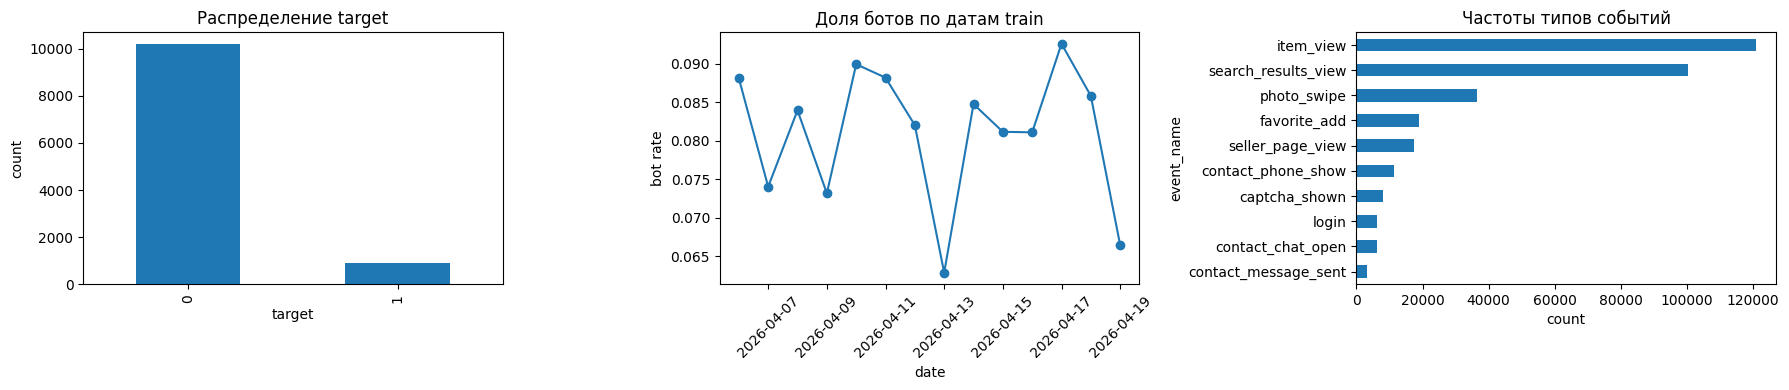

In [3]:
# ============================================================
# Небольшие визуализации EDA
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# 1. Распределение target
train.target.value_counts().sort_index().plot(kind='bar', ax=axes[0])
axes[0].set_title('Распределение target')
axes[0].set_xlabel('target')
axes[0].set_ylabel('count')

# 2. Доля ботов по датам
daily = (
    train.assign(date=train.window_start_ts.dt.date)
    .groupby('date')
    .agg(n_cookies=('cookie_id', 'size'), bot_rate=('target', 'mean'))
)
daily['bot_rate'].plot(marker='o', ax=axes[1])
axes[1].set_title('Доля ботов по датам train')
axes[1].set_xlabel('date')
axes[1].set_ylabel('bot rate')
axes[1].tick_params(axis='x', rotation=45)

# 3. Топ событий
events.event_name.value_counts().head(10).sort_values().plot(kind='barh', ax=axes[2])
axes[2].set_title('Частоты типов событий')
axes[2].set_xlabel('count')

plt.tight_layout()
plt.show()

### Наблюдения после первичного анализа

1. Класс положительных объектов заметно меньше отрицательного, поэтому accuracy не является содержательной метрикой.
2. Тестовые cookie относятся к более позднему периоду, поэтому валидация должна быть хронологической.
3. События включают разные сценарии поведения: просмотр объявлений, поиск, фотографии, контакты, избранное, вход и капчу.
4. Координаты указателя заполнены не для всех платформ и не для всех событий. Это важная неоднородность, которую нужно учитывать в модели.

## 4. Фильтрация событий по окнам наблюдения

Все признаки строятся только по событиям внутри индивидуального окна каждого cookie. Это ключевое условие временной корректности.

События за пределами окна не используются ни при обучении, ни при формировании test-предсказаний.

In [4]:
def filter_events_by_window(log, metadata):
    e = log.merge(metadata[['cookie_id', 'window_start_ts', 'window_end_ts']],
                  on='cookie_id', how='inner', validate='many_to_one', sort=False)
    inside = e.event_ts.ge(e.window_start_ts) & e.event_ts.lt(e.window_end_ts)
    return e.loc[inside].copy().reset_index(drop=True)

ev_train = filter_events_by_window(events, train)
ev_test = filter_events_by_window(events, test)
for name, frame, meta in [('TRAIN', ev_train, train), ('TEST', ev_test, test)]:
    assert frame.cookie_id.isin(meta.cookie_id).all()
    assert (frame.event_ts.ge(frame.window_start_ts) & frame.event_ts.lt(frame.window_end_ts)).all()
    print(name, 'событий:', len(frame), '| после удаления полных дубликатов:', len(frame.drop_duplicates()))
assert len(ev_train) == 198436 and len(ev_test) == 89690, 'Контрольное количество событий отличается; проверьте исходные файлы.'
assert not ev_train.event_name.eq('captcha_shown').any()
assert not ev_test.event_name.eq('captcha_shown').any()

TRAIN событий: 198436 | после удаления полных дубликатов: 195484
TEST событий: 89690 | после удаления полных дубликатов: 88349


,n_events,n_cookies,pointer_ratio
platform_norm,,,
web,110007,5917,0.6022
android,77991,4595,0.0000
ios,10438,579,0.0000


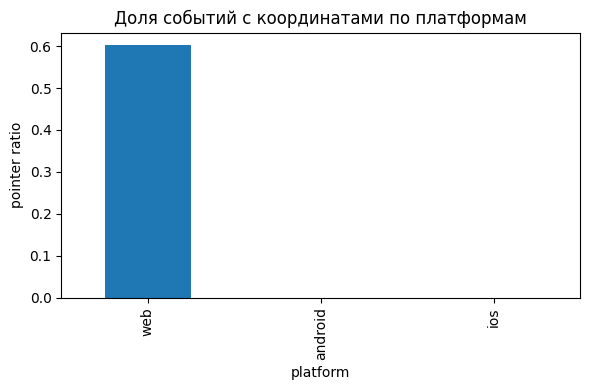

In [5]:
# ============================================================
# Доступность координат по платформам после временной фильтрации
# ============================================================

platform_view = ev_train.copy()
platform_view['platform_norm'] = (
    platform_view['platform']
    .str.lower()
    .replace({'desktop': 'web', 'iphone': 'ios'})
)
platform_view['has_pointer'] = (
    platform_view['pointer_x'].notna() &
    platform_view['pointer_y'].notna()
)

platform_stats = (
    platform_view.groupby('platform_norm')
    .agg(
        n_events=('cookie_id', 'size'),
        n_cookies=('cookie_id', 'nunique'),
        pointer_ratio=('has_pointer', 'mean')
    )
    .sort_values('n_events', ascending=False)
)

display(platform_stats.round(4))

platform_stats['pointer_ratio'].plot(kind='bar', figsize=(6, 4))
plt.title('Доля событий с координатами по платформам')
plt.xlabel('platform')
plt.ylabel('pointer ratio')
plt.tight_layout()
plt.show()

### Почему координаты стали отдельной частью решения

После фильтрации видно, что координаты указателя доступны неравномерно. На мобильных платформах они отсутствуют, а в web-трафике встречаются только у части событий.

Это привело к двум решениям:

1. рассчитывать отдельный блок признаков, описывающих распределение координат;
2. в финальной архитектуре использовать специализированные модели для cookie с координатами и без них.

## 5. Гипотезы для построения признаков

Перед построением модели были сформулированы несколько поведенческих гипотез.

### Гипотеза 1. Темп активности отличается у автоматизированного трафика
Автоматизированные сценарии могут давать более короткие или более регулярные интервалы между событиями.

### Гипотеза 2. Важно разнообразие интересов
Сервис автоматического сбора может просматривать много объявлений, категорий и локаций, но делать это с иной структурой, чем обычный пользователь.

### Гипотеза 3. Поисковое поведение несёт сигнал
Глубина выдачи, число запросов и распределение страниц поиска могут отражать сценарий сбора данных.

### Гипотеза 4. Координаты указателя помогают отличать реальные взаимодействия от шаблонных
Даже если координаты не являются непрерывной траекторией мыши, распределение зарегистрированных позиций может быть информативным.

### Гипотеза 5. Одна универсальная модель может быть недостаточной
Так как часть cookie имеет координаты, а часть — нет, имеет смысл объединить общую модель со специализированными моделями по доступности координат.

## 6. Конструирование поведенческих признаков

Одна строка итоговой таблицы соответствует одному `cookie_id`. Журнал событий агрегируется в признаки нескольких типов:

- активность и разнообразие;
- временная динамика;
- сессии и короткие серии действий;
- распределение типов событий;
- поисковое поведение;
- координаты указателя;
- повторяемость и концентрация поведения.

Ниже функции объединены в тематические блоки. Комментарии в коде оставлены подробными, чтобы было видно, из какой поведенческой гипотезы появился каждый блок признаков.

### 6.1. Активность, разнообразие, дубликаты и базовые временные статистики

In [6]:
def make_activity_features(ev, meta):
    ev = ev.copy()

    # Нормализация platform
    ev['platform_norm'] = ev['platform'].str.lower()

    # Сортировка нужна для временных признаков
    ev = ev.sort_values(['cookie_id', 'event_ts'])

    # Отмечаем полные дубликаты
    event_cols = [
        'cookie_id', 'event_ts', 'eid', 'event_name', 'platform',
        'user_agent', 'item_id', 'item_category', 'item_location',
        'seller_type', 'search_query', 'search_page',
        'pointer_x', 'pointer_y'
    ]

    ev['is_duplicate'] = ev.duplicated(subset=event_cols, keep='first').astype(int)

    # Интервал до предыдущего события внутри cookie
    ev['delta_sec'] = (
        ev.groupby('cookie_id')['event_ts']
          .diff()
          .dt.total_seconds()
    )

    g = ev.groupby('cookie_id')

    features = pd.DataFrame(index=g.size().index)

    # -------------------------
    # Общая активность
    # -------------------------
    features['n_events'] = g.size()
    features['n_unique_event_types'] = g['event_name'].nunique()

    features['item_nunique'] = g['item_id'].nunique()
    features['category_nunique'] = g['item_category'].nunique()
    features['location_nunique'] = g['item_location'].nunique()

    features['search_query_nunique'] = g['search_query'].nunique()
    features['search_page_max'] = g['search_page'].max()
    features['search_page_mean'] = g['search_page'].mean()

    features['platform_nunique'] = g['platform_norm'].nunique()
    features['ua_nunique'] = g['user_agent'].nunique()

    # -------------------------
    # Дубликаты
    # -------------------------
    features['n_duplicate_events'] = g['is_duplicate'].sum()
    features['duplicate_ratio'] = (
        features['n_duplicate_events'] / features['n_events']
    )

    # -------------------------
    # Временные признаки
    # -------------------------
    features['delta_mean'] = g['delta_sec'].mean()
    features['delta_median'] = g['delta_sec'].median()
    features['delta_std'] = g['delta_sec'].std()
    features['delta_min'] = g['delta_sec'].min()
    features['delta_max'] = g['delta_sec'].max()

    features['delta_q10'] = g['delta_sec'].quantile(0.10)
    features['delta_q25'] = g['delta_sec'].quantile(0.25)
    features['delta_q75'] = g['delta_sec'].quantile(0.75)
    features['delta_q90'] = g['delta_sec'].quantile(0.90)

    # Очень быстрые последовательные действия
    for threshold in [1, 2, 5, 10, 30, 60]:
        tmp = (
            ev.assign(x=(ev['delta_sec'] <= threshold).astype(float))
              .groupby('cookie_id')['x']
              .mean()
        )
        features[f'delta_le_{threshold}s_ratio'] = tmp

    # -------------------------
    # Координаты курсора
    # -------------------------
    features['pointer_present_ratio'] = (
        ev['pointer_x'].notna()
        .groupby(ev['cookie_id'])
        .mean()
    )

    features['pointer_x_nunique'] = g['pointer_x'].nunique()
    features['pointer_y_nunique'] = g['pointer_y'].nunique()

    # -------------------------
    # Количество каждого типа события
    # -------------------------
    event_counts = pd.crosstab(
        ev['cookie_id'],
        ev['event_name']
    )

    event_counts.columns = [
        f'event_count__{c}' for c in event_counts.columns
    ]

    features = features.join(event_counts)

    # -------------------------
    # Доли каждого типа события
    # -------------------------
    for col in event_counts.columns:
        ratio_col = col.replace('event_count__', 'event_ratio__')
        features[ratio_col] = (
            features[col] / features['n_events']
        )

    # -------------------------
    # User-Agent: простые семантические признаки
    # -------------------------
    ua = ev['user_agent'].str.lower()

    ua_features = pd.DataFrame({
        'cookie_id': ev['cookie_id'],
        'ua_headless': ua.str.contains('headless', na=False).astype(int),
        'ua_mobile': ua.str.contains(
            'mobile|android|iphone|ipad',
            regex=True,
            na=False
        ).astype(int),
        'ua_chrome': ua.str.contains('chrome', na=False).astype(int),
        'ua_firefox': ua.str.contains('firefox', na=False).astype(int),
        'ua_yandex': ua.str.contains('yabrowser', na=False).astype(int),
    })

    ua_agg = ua_features.groupby('cookie_id').mean()
    features = features.join(ua_agg)

    # -------------------------
    # Возраст cookie
    # -------------------------
    meta_tmp = meta.set_index('cookie_id')

    cookie_age = (
        meta_tmp['window_start_ts']
        - meta_tmp['cookie_created_at']
    ).dt.total_seconds()

    features['cookie_age_hours'] = cookie_age / 3600

    # -------------------------
    # Возвращаем все cookie,
    # даже если событий нет
    # -------------------------
    features = (
        meta[['cookie_id']]
        .merge(
            features.reset_index(),
            on='cookie_id',
            how='left'
        )
    )

    return features.fillna(0)

### 6.2. Сессии, разнообразие контента и переходы между действиями

In [7]:
def make_temporal_and_navigation_features(ev, meta):

    # Удаляем полные дубликаты для анализа поведения.
    # Исходные признаки количества дубликатов остаются в базовом блоке.
    e = ev.drop_duplicates().copy()

    e = e.sort_values(
        ['cookie_id', 'event_ts'],
        kind='mergesort'
    )

    g = e.groupby('cookie_id')

    f = pd.DataFrame(index=g.size().index)

    # ==================================
    # 1. Разнообразие активности
    # ==================================

    n_events = g.size()
    n_items = g.item_id.nunique()

    f['unique_items_per_event'] = (
        n_items / n_events
    )

    f['categories_per_item'] = (
        g.item_category.nunique() /
        n_items.replace(0, np.nan)
    )

    f['locations_per_item'] = (
        g.item_location.nunique() /
        n_items.replace(0, np.nan)
    )

    # Количество просмотров относительно
    # числа уникальных объявлений
    f['events_per_item'] = (
        n_events / n_items.replace(0, np.nan)
    )

    # ==================================
    # 2. Временная активность
    # ==================================

    e['delta'] = (
        g.event_ts.diff()
        .dt.total_seconds()
    )

    dt = e.groupby('cookie_id')['delta']

    f['clean_delta_mean'] = dt.mean()
    f['clean_delta_median'] = dt.median()
    f['clean_delta_std'] = dt.std()

    f['clean_delta_cv'] = (
        f['clean_delta_std'] /
        (f['clean_delta_mean'] + 1)
    )

    # Интервалы между первым и последним событием
    duration = (
        g.event_ts.max() -
        g.event_ts.min()
    ).dt.total_seconds()

    f['activity_duration_sec'] = duration

    f['events_per_active_hour'] = (
        n_events /
        (duration / 3600 + 1)
    )

    # ==================================
    # 3. Сессионная активность
    # ==================================

    # Новая сессия начинается после
    # перерыва более 30 минут

    e['new_session'] = (
        e['delta'].isna() |
        (e['delta'] > 1800)
    ).astype(int)

    f['n_sessions'] = (
        e.groupby('cookie_id')['new_session'].sum()
    )

    f['events_per_session'] = (
        n_events /
        f['n_sessions'].replace(0, np.nan)
    )

    # ==================================
    # 4. Повторяемость объявлений
    # ==================================

    items = e[e.item_id.notna()]

    item_counts = (
        items.groupby(['cookie_id', 'item_id'])
        .size()
        .groupby(level=0)
    )

    f['max_item_repeats'] = item_counts.max()
    f['mean_item_repeats'] = item_counts.mean()

    # ==================================
    # 5. Энтропия категорий
    # ==================================

    # Насколько равномерно распределена
    # активность между категориями

    category_counts = (
        e.dropna(subset=['item_category'])
        .groupby(['cookie_id', 'item_category'])
        .size()
    )

    category_prob = (
        category_counts /
        category_counts.groupby(level=0).transform('sum')
    )

    entropy = (
        -(category_prob * np.log(category_prob))
        .groupby(level=0)
        .sum()
    )

    f['category_entropy'] = entropy

    # ==================================
    # 6. Последовательности событий
    # ==================================

    e['prev_event'] = (
        e.groupby('cookie_id')['event_name'].shift(1)
    )

    e['transition'] = (
        e['prev_event'].fillna('START') +
        '__TO__' +
        e['event_name']
    )

    # Переходы учитываем только при строго
    # положительном интервале между событиями:
    # порядок разных событий с одинаковым
    # timestamp может быть неоднозначным.
    transitions = [
        ('search_results_view', 'item_view'),
        ('item_view', 'photo_swipe'),
        ('item_view', 'seller_page_view'),
        ('item_view', 'contact_phone_show'),
        ('item_view', 'favorite_add'),
        ('seller_page_view', 'contact_phone_show'),
        ('contact_chat_open', 'contact_message_sent'),
    ]

    for prev, curr in transitions:

        name = f'transition__{prev}__{curr}'

        mask = (
            (e['prev_event'] == prev) &
            (e['event_name'] == curr) &
            (e['delta'] > 0)
        )

        counts = (
            mask.groupby(e['cookie_id']).sum()
        )

        f[name] = counts

        f[name + '_ratio'] = (
            counts / n_events
        )

    # ==================================
    # 7. Присоединяем к cookie
    # ==================================

    f = (
        meta[['cookie_id']]
        .merge(
            f.reset_index(),
            on='cookie_id',
            how='left'
        )
    )

    return f.fillna(0)

### 6.3. Интенсивность, поисковое поведение и координаты указателя

In [8]:
def make_intensity_and_engagement_features(ev, meta):

    e = ev.drop_duplicates().copy()

    e = e.sort_values(
        ['cookie_id', 'event_ts'],
        kind='mergesort'
    )

    g = e.groupby('cookie_id')
    f = pd.DataFrame(index=g.size().index)

    n = g.size()

    # ==============================================
    # Вспомогательная функция: концентрация
    # ==============================================

    def distribution_features(column, prefix):

        # Пропуски не считаем отдельной категорией
        tmp = e.dropna(subset=[column])

        counts = (
            tmp.groupby(['cookie_id', column])
            .size()
        )

        if counts.empty:
            return

        total = counts.groupby(level=0).transform('sum')
        p = counts / total

        # Энтропия Шеннона
        entropy = (
            -(p * np.log(p))
            .groupby(level=0)
            .sum()
        )

        # Максимальная доля одной категории / локации / запроса
        top_share = (
            p.groupby(level=0)
            .max()
        )

        # Индекс концентрации (HHI)
        concentration = (
            p.pow(2)
            .groupby(level=0)
            .sum()
        )

        # Число значений, встречавшихся более одного раза
        repeated = (
            counts.gt(1)
            .groupby(level=0)
            .sum()
        )

        f[f'{prefix}_entropy_v3'] = entropy
        f[f'{prefix}_top_share_v3'] = top_share
        f[f'{prefix}_hhi_v3'] = concentration
        f[f'{prefix}_repeated_v3'] = repeated

    distribution_features('item_id', 'item')
    distribution_features('item_category', 'category')
    distribution_features('item_location', 'location')
    distribution_features('search_query', 'query')

    # ==============================================
    # 1. Временные признаки
    # ==============================================

    e['dt'] = (
        g.event_ts.diff()
        .dt.total_seconds()
    )

    dt = e.groupby('cookie_id')['dt']

    f['v3_dt_zero_ratio'] = (
        e['dt'].eq(0)
        .groupby(e.cookie_id)
        .mean()
    )

    f['v3_dt_gt_5min_ratio'] = (
        e['dt'].gt(300)
        .groupby(e.cookie_id)
        .mean()
    )

    f['v3_dt_gt_30min_ratio'] = (
        e['dt'].gt(1800)
        .groupby(e.cookie_id)
        .mean()
    )

    # Разброс относительно среднего
    f['v3_dt_cv'] = (
        dt.std() / (dt.mean() + 1)
    )

    # Разница между верхним и нижним квантилями
    f['v3_dt_iqr'] = (
        dt.quantile(0.75) -
        dt.quantile(0.25)
    )

    # ==============================================
    # 2. Активность по минутам
    # ==============================================

    e['minute_bin'] = e.event_ts.dt.floor('min')

    minute_counts = (
        e.groupby(['cookie_id', 'minute_bin'])
        .size()
    )

    minute_g = minute_counts.groupby(level=0)

    f['v3_max_events_per_min'] = minute_g.max()
    f['v3_mean_events_per_active_min'] = minute_g.mean()
    f['v3_std_events_per_active_min'] = minute_g.std()

    f['v3_n_active_minutes'] = minute_g.size()

    f['v3_events_per_active_min'] = (
        n / f['v3_n_active_minutes']
    )

    # Аналогично для пятиминутных интервалов
    e['five_min_bin'] = e.event_ts.dt.floor('5min')

    five_counts = (
        e.groupby(['cookie_id', 'five_min_bin'])
        .size()
    )

    f['v3_max_events_per_5min'] = (
        five_counts.groupby(level=0).max()
    )

    # ==============================================
    # 3. Максимальная серия быстрых событий
    # ==============================================

    def max_fast_streak(s, threshold):

        fast = s.le(threshold) & s.notna()

        # Разделяем последовательность на группы,
        # когда встречается медленное событие
        blocks = (~fast).cumsum()

        return int(
            fast.groupby(blocks).sum().max()
        )

    for threshold in [2, 5, 10, 30]:

        f[f'v3_max_streak_{threshold}s'] = (
            dt.apply(
                lambda x: max_fast_streak(x, threshold)
            )
        )

    # ==============================================
    # 4. Поисковое поведение
    # ==============================================

    search = e[
        e.event_name == 'search_results_view'
    ].copy()

    search['search_page_num'] = pd.to_numeric(
        search.search_page,
        errors='coerce'
    )

    sg = search.groupby('cookie_id')

    f['v3_search_count'] = sg.size()

    # Глубина просмотра выдачи
    f['v3_search_page_std'] = sg.search_page_num.std()

    for page in [2, 3, 5, 10]:

        f[f'v3_search_page_ge_{page}_ratio'] = (
            search.search_page_num.ge(page)
            .groupby(search.cookie_id)
            .mean()
        )

    # Число разных страниц выдачи
    f['v3_search_page_nunique'] = (
        sg.search_page_num.nunique()
    )

    # Максимальная глубина для отдельного запроса
    query_depth = (
        search.dropna(subset=['search_query'])
        .groupby(['cookie_id', 'search_query'])
        .search_page_num.max()
    )

    f['v3_max_query_depth'] = (
        query_depth.groupby(level=0).max()
    )

    f['v3_mean_query_depth'] = (
        query_depth.groupby(level=0).mean()
    )

    # ==============================================
    # 5. Контактные действия и воронка
    # ==============================================

    event_counts = pd.crosstab(
        e.cookie_id,
        e.event_name
    )

    def count_event(name):
        return event_counts.get(
            name,
            pd.Series(0, index=f.index)
        ).reindex(f.index, fill_value=0)

    views = count_event('item_view')
    searches = count_event('search_results_view')
    phones = count_event('contact_phone_show')
    chats = count_event('contact_chat_open')
    messages = count_event('contact_message_sent')
    favorites = count_event('favorite_add')
    photos = count_event('photo_swipe')
    seller_views = count_event('seller_page_view')

    contacts = phones + chats + messages

    n_items = g.item_id.nunique()

    f['v3_contacts_per_view'] = (
        contacts / (views + 1)
    )

    f['v3_contacts_per_item'] = (
        contacts / (n_items + 1)
    )

    f['v3_views_per_search'] = (
        views / (searches + 1)
    )

    f['v3_photos_per_view'] = (
        photos / (views + 1)
    )

    f['v3_sellers_per_view'] = (
        seller_views / (views + 1)
    )

    f['v3_favorites_per_view'] = (
        favorites / (views + 1)
    )

    f['v3_messages_per_chat'] = (
        messages / (chats + 1)
    )

    # Доля контактных действий среди всех событий
    f['v3_contact_ratio'] = (
        contacts / n
    )

    # ==============================================
    # 6. Поведение курсора
    # ==============================================

    pointer = e.dropna(
        subset=['pointer_x', 'pointer_y']
    ).copy()

    pg = pointer.groupby('cookie_id')

    f['v3_pointer_n'] = pg.size()

    # Разнообразие координат
    f['v3_pointer_x_std'] = pg.pointer_x.std()
    f['v3_pointer_y_std'] = pg.pointer_y.std()

    f['v3_pointer_x_range'] = (
        pg.pointer_x.max() - pg.pointer_x.min()
    )

    f['v3_pointer_y_range'] = (
        pg.pointer_y.max() - pg.pointer_y.min()
    )

    # Сколько уникальных пар координат
    unique_xy = (
        pointer.groupby('cookie_id')
        .apply(
            lambda x: x[['pointer_x', 'pointer_y']]
            .drop_duplicates()
            .shape[0],
            include_groups=False
        )
    )

    f['v3_unique_pointer_positions'] = unique_xy

    f['v3_pointer_unique_ratio'] = (
        unique_xy / f['v3_pointer_n']
    )

    # ==============================================
    # 7. Активность внутри окна
    # ==============================================


    e['hours_from_start'] = (
        e.event_ts - e.window_start_ts
    ).dt.total_seconds() / 3600

    f['v3_first_hour_ratio'] = (
        e.hours_from_start.lt(1)
        .groupby(e.cookie_id)
        .mean()
    )

    f['v3_last_hour_ratio'] = (
        e.hours_from_start.ge(23)
        .groupby(e.cookie_id)
        .mean()
    )

    f['v3_active_hours'] = (
        e.groupby('cookie_id')
        .event_ts
        .apply(lambda s: s.dt.floor('h').nunique())
    )

    # ==============================================
    # Объединение
    # ==============================================

    f = (
        meta[['cookie_id']]
        .merge(
            f.reset_index(),
            on='cookie_id',
            how='left',
            validate='one_to_one'
        )
    )

    return f.replace(
        [np.inf, -np.inf], np.nan
    ).fillna(0)

### 6.4. Повторяемость и распределение координат указателя

In [9]:
def make_pointer_distribution_features(ev, meta):

    e = ev.drop_duplicates().copy()

    e = e.dropna(
        subset=['pointer_x', 'pointer_y']
    )

    f = meta[['cookie_id']].copy()

    if e.empty:
        return f

    g = e.groupby('cookie_id')

    result = pd.DataFrame(index=g.size().index)

    n = g.size()

    # Доля уникальных значений каждой координаты
    result['p4_x_unique_ratio'] = (
        g.pointer_x.nunique() / n
    )

    result['p4_y_unique_ratio'] = (
        g.pointer_y.nunique() / n
    )

    # Относительный разброс координат.
    # Сначала берём модуль значений, затем группируем по cookie_id.

    result['p4_x_cv'] = (
        g['pointer_x'].std() /
        (
            e['pointer_x'].abs()
            .groupby(e['cookie_id'])
            .mean() + 1
        )
    )

    result['p4_y_cv'] = (
        g['pointer_y'].std() /
        (
            e['pointer_y'].abs()
            .groupby(e['cookie_id'])
            .mean() + 1
        )
    )

    # Повторяемость конкретных пар координат
    xy_counts = (
        e.groupby(
            ['cookie_id', 'pointer_x', 'pointer_y']
        )
        .size()
    )

    xy_grouped = xy_counts.groupby(level=0)

    result['p4_max_position_repeats'] = (
        xy_grouped.max()
    )

    result['p4_top_position_ratio'] = (
        xy_grouped.max() / n
    )

    result['p4_repeated_positions'] = (
        xy_counts.gt(1)
        .groupby(level=0)
        .sum()
    )

    # Разброс координат внутри отдельных типов событий
    for event in [
        'item_view',
        'search_results_view',
        'photo_swipe',
        'seller_page_view',
        'contact_phone_show'
    ]:

        part = e[e.event_name == event]

        pg = part.groupby('cookie_id')

        result[f'p4_{event}_x_std'] = (
            pg.pointer_x.std()
        )

        result[f'p4_{event}_y_std'] = (
            pg.pointer_y.std()
        )

        result[f'p4_{event}_pointer_n'] = (
            pg.size()
        )

    # Присоединяем признаки ко всем cookie
    f = f.merge(
        result.reset_index(),
        on='cookie_id',
        how='left',
        validate='one_to_one'
    )

    return f.replace(
        [np.inf, -np.inf],
        np.nan
    ).fillna(0)

### 6.5. Объединение признаков

In [10]:
def build_feature_matrix(ev, metadata):
    blocks = [
        make_activity_features(ev, metadata),
        make_temporal_and_navigation_features(ev, metadata),
        make_intensity_and_engagement_features(ev, metadata),
        make_pointer_distribution_features(ev, metadata),
    ]
    X = metadata[['cookie_id']].copy()
    for block in blocks:
        assert block.cookie_id.is_unique
        X = X.merge(block, on='cookie_id', how='left', validate='one_to_one', sort=False)
    columns = [c for c in X if c != 'cookie_id']
    assert X.cookie_id.reset_index(drop=True).equals(metadata.cookie_id.reset_index(drop=True))
    assert len(columns) == len(set(columns))
    X[columns] = X[columns].astype('float64').replace([np.inf,-np.inf],np.nan).fillna(0)
    assert np.isfinite(X[columns].to_numpy(dtype=float)).all()
    return X

X_train = build_feature_matrix(ev_train, train)
X_test = build_feature_matrix(ev_test, test)
FEATURES = [c for c in X_train if c != 'cookie_id']
assert len(FEATURES) == 163, f'Ожидалось 163 признака, получено {len(FEATURES)}'
assert X_train.columns.equals(X_test.columns)
assert len(X_train) == len(train) and len(X_test) == len(test)
assert (X_train[FEATURES].nunique(dropna=False) > 1).all(), 'Обнаружены константные обучающие признаки'
y = train.target.to_numpy(dtype=int)
print('Матрицы:', X_train.shape, X_test.shape)
print('Количество признаков:', len(FEATURES))

Матрицы: (11091, 164) (4909, 164)
Количество признаков: 163


### Краткий обзор полученной матрицы признаков

Финальная таблица содержит 163 числовых признака на каждый cookie. Все признаки рассчитываются одинаково для train и test, а порядок строк сохраняет порядок исходных `train.csv` и `test.csv`.

In [11]:
# ============================================================
# Обзор полученных признаков
# ============================================================

print('Train feature matrix:', X_train.shape)
print('Test feature matrix:', X_test.shape)
print('Количество признаков:', len(FEATURES))

feature_groups = {
    'События и доли событий': sum(c.startswith('event_') for c in FEATURES),
    'Временные признаки': sum(('delta' in c or 'duration' in c or 'streak' in c or 'session' in c) for c in FEATURES),
    'Поиск': sum(('search' in c or 'query' in c) for c in FEATURES),
    'Координаты указателя': sum(('pointer' in c or c.startswith('p4_')) for c in FEATURES),
    'User-Agent': sum(c.startswith('ua_') for c in FEATURES),
}

display(pd.Series(feature_groups, name='n_features').to_frame())

Train feature matrix: (11091, 164)
Test feature matrix: (4909, 164)
Количество признаков: 163


,n_features
События и доли событий,18
Временные признаки,26
Поиск,24
Координаты указателя,32
User-Agent,6


## 7. Baseline и последовательное развитие признаков

Перед выбором финальной архитектуры важно проверить, что прирост качества связан не только с более сложной моделью, но и с осмысленными поведенческими признаками.

В качестве отправной точки используется простой baseline из quickstart: количество событий и число уникальных объявлений. Затем признаки добавляются тематическими блоками:

1. **Активность и типы событий** — объём действий, доли событий, разнообразие объявлений, категорий и локаций.
2. **Временная динамика и сессии** — интервалы между событиями, короткие серии действий, длительность активности.
3. **Поиск, концентрация поведения и координаты** — глубина выдачи, повторяемость, энтропии категорий и локаций, признаки указателя.
4. **Полный набор признаков** — все рассчитанные поведенческие характеристики.

Такое сравнение показывает, какие группы признаков действительно добавляют информацию, а не просто увеличивают размер таблицы.

In [12]:
# ============================================================
# Baseline и сравнение групп признаков
# ============================================================

from sklearn.ensemble import RandomForestClassifier

VALIDATION_FOLDS = [
    ('11–13 апреля', '2026-04-11', '2026-04-14'),
    ('14–16 апреля', '2026-04-14', '2026-04-17'),
    ('17–19 апреля', '2026-04-17', '2026-04-20'),
]

# Для исследовательского сравнения используем один seed и ту же хронологическую валидацию.
# Финальная модель ниже будет обучаться уже как multiseed-ансамбль.

def evaluate_single_model(X, columns, model_factory, model_name):
    rows = []

    for fold_name, start, end in VALIDATION_FOLDS:
        train_mask = train.window_start_ts.lt(pd.Timestamp(start, tz='UTC')).to_numpy()
        valid_mask = (
            train.window_start_ts.ge(pd.Timestamp(start, tz='UTC')) &
            train.window_start_ts.lt(pd.Timestamp(end, tz='UTC'))
        ).to_numpy()

        model = model_factory()
        model.fit(X.loc[train_mask, columns], y[train_mask])
        pred = model.predict_proba(X.loc[valid_mask, columns])[:, 1]

        rows.append({
            'Модель / признаки': model_name,
            'Период': fold_name,
            'Precision@Recall≥0.70': precision_at_recall(y[valid_mask], pred),
            'PR-AUC': average_precision_score(y[valid_mask], pred),
            'ROC-AUC': roc_auc_score(y[valid_mask], pred),
        })

    return pd.DataFrame(rows)

# Колонки простого baseline из quickstart.
baseline_columns = ['n_events', 'item_nunique']
assert set(baseline_columns).issubset(FEATURES)

# Колонки тематических блоков извлекаются из тех же функций, которыми строится финальная матрица.
# Это нужно только для исследовательского сравнения групп признаков.
activity_cols = [c for c in make_activity_features(ev_train, train).columns if c != 'cookie_id']
temporal_cols = [c for c in make_temporal_and_navigation_features(ev_train, train).columns if c != 'cookie_id']
intensity_cols = [c for c in make_intensity_and_engagement_features(ev_train, train).columns if c != 'cookie_id']
pointer_cols = [c for c in make_pointer_distribution_features(ev_train, train).columns if c != 'cookie_id']

def unique_columns(columns):
    seen = set()
    result = []
    for col in columns:
        if col not in seen:
            seen.add(col)
            result.append(col)
    return result

feature_sets_for_story = {
    'Baseline: 2 простых признака': baseline_columns,
    'Активность и типы событий': unique_columns(activity_cols),
    'Активность + время + сессии': unique_columns(activity_cols + temporal_cols),
    'Все поведенческие признаки': FEATURES,
}

# Baseline оставлен на RandomForest, как в quickstart.
# Остальные конфигурации оцениваются CatBoost с одним seed=42.
comparison_parts = []
comparison_parts.append(
    evaluate_single_model(
        X_train,
        feature_sets_for_story['Baseline: 2 простых признака'],
        lambda: RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=3,
            random_state=42,
            n_jobs=-1
        ),
        'Baseline: 2 простых признака'
    )
)

for name, cols in list(feature_sets_for_story.items())[1:]:
    comparison_parts.append(
        evaluate_single_model(
            X_train,
            cols,
            lambda: CatBoostClassifier(
                iterations=500,
                depth=6,
                learning_rate=0.035,
                l2_leaf_reg=5,
                loss_function='Logloss',
                random_seed=42,
                verbose=False,
                thread_count=-1,
                allow_writing_files=False,
            ),
            name
        )
    )

feature_comparison = pd.concat(comparison_parts, ignore_index=True)
display(feature_comparison.round(4))

feature_summary = feature_comparison.pivot(
    index='Модель / признаки',
    columns='Период',
    values='Precision@Recall≥0.70'
)
feature_summary['Среднее'] = feature_summary.mean(axis=1)

display(
    feature_summary.sort_values('Среднее', ascending=False).round(4)
)

,Модель / признаки,Период,Precision@Recall≥0.70,PR-AUC,ROC-AUC
0,Baseline: 2 простых признака,11–13 апреля,0.0964,0.2337,0.6397
1,Baseline: 2 простых признака,14–16 апреля,0.1050,0.2330,0.6380
2,Baseline: 2 простых признака,17–19 апреля,0.1062,0.1804,0.6081
3,Активность и типы событий,11–13 апреля,0.4502,0.6724,0.8771
4,Активность и типы событий,14–16 апреля,0.4982,0.7068,0.9094
5,Активность и типы событий,17–19 апреля,0.6154,0.7094,0.8949
6,Активность + время + сессии,11–13 апреля,0.4459,0.6807,0.8974
7,Активность + время + сессии,14–16 апреля,0.6372,0.7294,0.9206
8,Активность + время + сессии,17–19 апреля,0.5864,0.6968,0.9007
9,Все поведенческие признаки,11–13 апреля,0.6604,0.7527,0.9278


Период,11–13 апреля,14–16 апреля,17–19 апреля,Среднее
Модель / признаки,,,,
Все поведенческие признаки,0.6604,0.7611,0.7635,0.7283
Активность + время + сессии,0.4459,0.6372,0.5864,0.5565
Активность и типы событий,0.4502,0.4982,0.6154,0.5212
Baseline: 2 простых признака,0.0964,0.1050,0.1062,0.1025


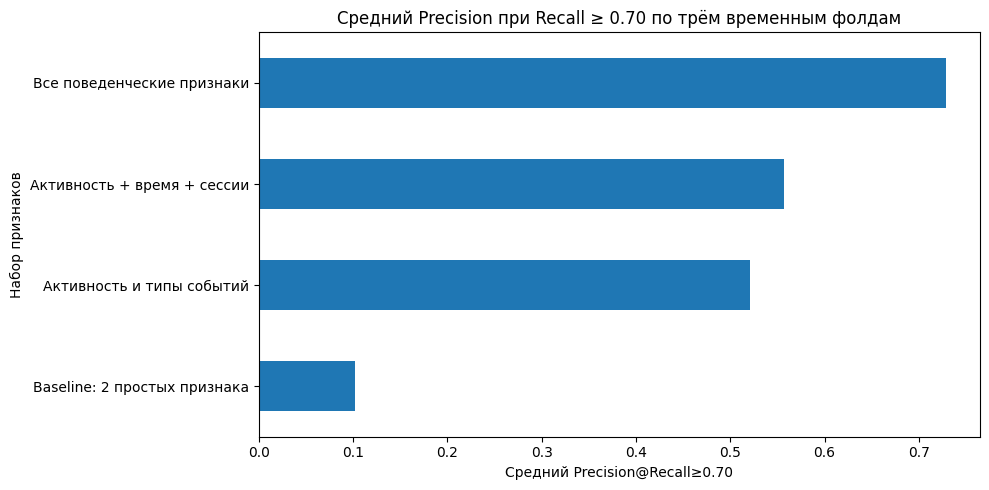

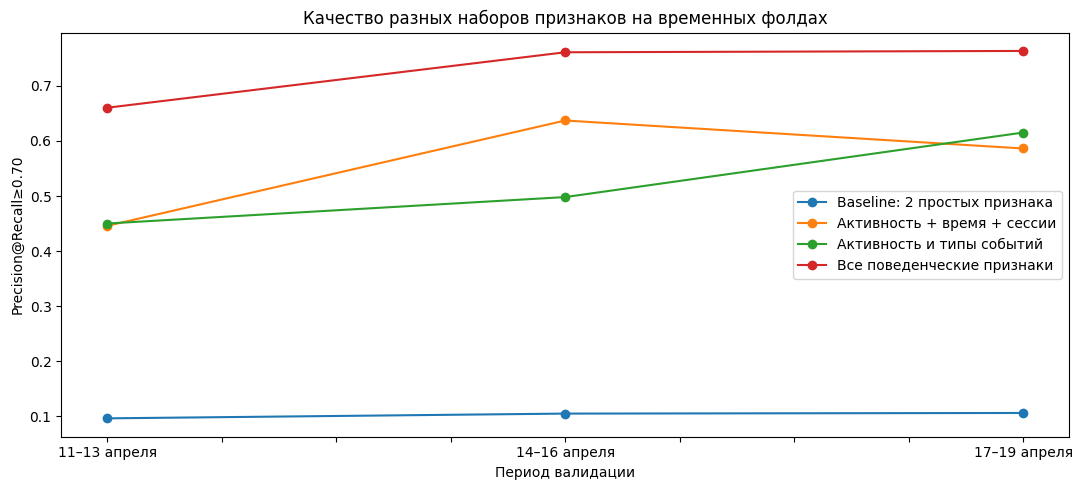

In [13]:
# ============================================================
# Визуальное сравнение вклада групп признаков
# ============================================================

feature_plot = feature_summary.sort_values('Среднее')

ax = feature_plot['Среднее'].plot(
    kind='barh',
    figsize=(10, 5)
)
ax.set_title('Средний Precision при Recall ≥ 0.70 по трём временным фолдам')
ax.set_xlabel('Средний Precision@Recall≥0.70')
ax.set_ylabel('Набор признаков')
plt.tight_layout()
plt.show()

# Детальная динамика по периодам.
feature_summary.drop(columns='Среднее').T.plot(
    marker='o',
    figsize=(11, 5)
)
plt.title('Качество разных наборов признаков на временных фолдах')
plt.xlabel('Период валидации')
plt.ylabel('Precision@Recall≥0.70')
plt.xticks(rotation=0)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

### Выводы из сравнения признаков

Простой baseline на двух агрегатах показывает, что одной интенсивности активности недостаточно. Существенный прирост дают признаки, описывающие структуру поведения:

- распределение типов событий;
- временные интервалы и короткие серии действий;
- разнообразие категорий, локаций и запросов;
- характеристики координат указателя.

Именно поэтому в финальной модели используется полный набор поведенческих признаков, а не только базовые счётчики. При этом дальнейшие гипотезы проверялись отдельно: часть из них дала локальный прирост, но не улучшала качество устойчиво на всех временных периодах.

## 8. Хронологическая валидация

Поскольку test расположен позже train, используется валидация по времени. На каждом фолде модель обучается только на более ранних датах и проверяется на более позднем периоде.

Проверяются три архитектуры:

- **global** — одна модель CatBoost на всех cookie;
- **specialized** — отдельные модели для cookie с координатами и без координат;
- **hybrid** — среднее предсказаний общей и специализированной частей.

Для устойчивости используется ансамбль из трёх фиксированных seed: `21`, `42`, `2026`.

In [14]:
VALIDATION_FOLDS = [
    ('11–13 апреля', '2026-04-11', '2026-04-14'),
    ('14–16 апреля', '2026-04-14', '2026-04-17'),
    ('17–19 апреля', '2026-04-17', '2026-04-20'),
]

POINTER_FEATURES = [c for c in FEATURES if (
    c.startswith('pointer_') or c.startswith('v3_pointer_')
    or c.startswith('p4_') or c == 'v3_unique_pointer_positions'
)]
NO_POINTER_FEATURES = [c for c in FEATURES if c not in POINTER_FEATURES]
assert 'v3_pointer_n' in FEATURES
HAS_POINTER_TRAIN = X_train['v3_pointer_n'].to_numpy(dtype=float) > 0
HAS_POINTER_TEST = X_test['v3_pointer_n'].to_numpy(dtype=float) > 0

def new_model(seed):
    return CatBoostClassifier(
        iterations=500, depth=6, learning_rate=0.035,
        l2_leaf_reg=5, loss_function='Logloss', random_seed=seed,
        verbose=False, thread_count=-1, allow_writing_files=False
    )

def ensemble_predict(train_mask, predict_X, predict_has_pointer):
    global_predictions, specialized_predictions = [], []
    for seed in SEEDS:
        global_model = new_model(seed)
        global_model.fit(X_train.loc[train_mask, FEATURES], y[train_mask])
        p_global = global_model.predict_proba(predict_X[FEATURES])[:, 1]
        p_specialized = np.full(len(predict_X), np.nan, dtype=float)
        for has_pointer in (False, True):
            training_group = train_mask & (HAS_POINTER_TRAIN == has_pointer)
            target_group = predict_has_pointer == has_pointer
            columns = FEATURES if has_pointer else NO_POINTER_FEATURES
            assert len(np.unique(y[training_group])) == 2, 'В группе отсутствует один из классов'
            model = new_model(seed)
            model.fit(X_train.loc[training_group, columns], y[training_group])
            if target_group.any():
                p_specialized[target_group] = model.predict_proba(predict_X.loc[target_group, columns])[:, 1]
        assert np.isfinite(p_specialized).all()
        global_predictions.append(p_global)
        specialized_predictions.append(p_specialized)
    global_score = np.mean(global_predictions, axis=0)
    specialized_score = np.mean(specialized_predictions, axis=0)
    hybrid_score = 0.5 * global_score + 0.5 * specialized_score
    return {'global': global_score, 'specialized': specialized_score, 'hybrid': hybrid_score}

In [15]:
validation_rows = []
for fold_name, start, end in VALIDATION_FOLDS:
    train_mask = train.window_start_ts.lt(pd.Timestamp(start, tz='UTC')).to_numpy()
    validation_mask = (train.window_start_ts.ge(pd.Timestamp(start, tz='UTC')) &
                       train.window_start_ts.lt(pd.Timestamp(end, tz='UTC'))).to_numpy()
    valid_X = X_train.loc[validation_mask].copy()
    scores = ensemble_predict(train_mask, valid_X, HAS_POINTER_TRAIN[validation_mask])
    for name, pred in scores.items():
        validation_rows.append({
            'Модель': name, 'Период': fold_name,
            'Precision@Recall≥0.70': precision_at_recall(y[validation_mask], pred),
            'PR-AUC': average_precision_score(y[validation_mask], pred),
            'ROC-AUC': roc_auc_score(y[validation_mask], pred),
        })
validation_result = pd.DataFrame(validation_rows)
display(validation_result.round(4))
validation_summary = validation_result.pivot(index='Модель', columns='Период', values='Precision@Recall≥0.70')
validation_summary['Среднее'] = validation_summary.mean(axis=1)
display(validation_summary.round(4))

# Контроль воспроизведения результатов исследовательского ноутбука:
reference = {'global': [0.6763, 0.7405, 0.7972], 'hybrid': [0.7071, 0.7254, 0.8175]}
for name, expected in reference.items():
    actual = validation_result.loc[validation_result['Модель'].eq(name), 'Precision@Recall≥0.70'].to_numpy()
    if not np.allclose(actual, expected, atol=0.00015):
        print(f'ВНИМАНИЕ: для {name} результат отличается от исследовательского: {actual} против {expected}')

,Модель,Период,Precision@Recall≥0.70,PR-AUC,ROC-AUC
0,global,11–13 апреля,0.6763,0.7508,0.9268
1,specialized,11–13 апреля,0.6651,0.7583,0.9307
2,hybrid,11–13 апреля,0.7071,0.7617,0.9300
3,global,14–16 апреля,0.7405,0.7920,0.9430
4,specialized,14–16 апреля,0.7366,0.7801,0.9386
5,hybrid,14–16 апреля,0.7254,0.7915,0.9422
6,global,17–19 апреля,0.7972,0.7742,0.9255
7,specialized,17–19 апреля,0.8071,0.7776,0.9247
8,hybrid,17–19 апреля,0.8175,0.7798,0.9266


Период,11–13 апреля,14–16 апреля,17–19 апреля,Среднее
Модель,,,,
global,0.6763,0.7405,0.7972,0.7380
hybrid,0.7071,0.7254,0.8175,0.7500
specialized,0.6651,0.7366,0.8071,0.7363


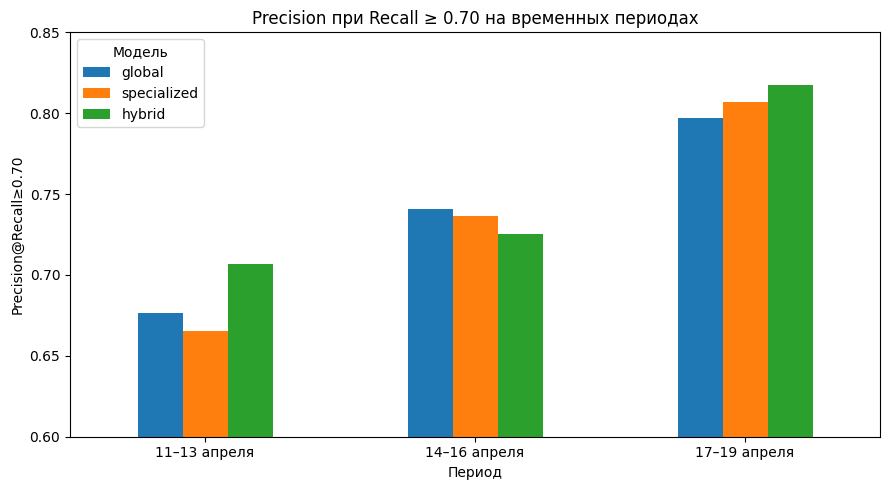

In [16]:
# ============================================================
# Визуальное сравнение моделей по основной метрике
# ============================================================

plot_df = validation_result.pivot(
    index='Период',
    columns='Модель',
    values='Precision@Recall≥0.70'
)
plot_df[['global', 'specialized', 'hybrid']].plot(kind='bar', figsize=(9, 5))
plt.title('Precision при Recall ≥ 0.70 на временных периодах')
plt.xlabel('Период')
plt.ylabel('Precision@Recall≥0.70')
plt.xticks(rotation=0)
plt.ylim(0.6, 0.85)
plt.tight_layout()
plt.show()

### Вывод по валидации

Гибридная архитектура показала наилучшее среднее качество по трём временным периодам.

Она не выигрывает на каждом фолде, но даёт лучший баланс:

- сохраняет информацию общей модели;
- использует различие между cookie с координатами и без них;
- улучшает ранжирование на двух из трёх временных периодов.

Поэтому именно гибридный ансамбль выбран в качестве основной финальной конфигурации.

## 9. Диагностика роли координат указателя

Важным наблюдением стала неоднородность качества для cookie с координатами и без них. Поэтому перед финальным обучением отдельно проверим распределение классов в этих группах.

target,0,1,All
Группа,,,
Есть координаты,3795,251,4046
Нет координат,6397,648,7045
All,10192,899,11091


,n,bot_rate
has_pointer,,
False,7045,0.092
True,4046,0.062


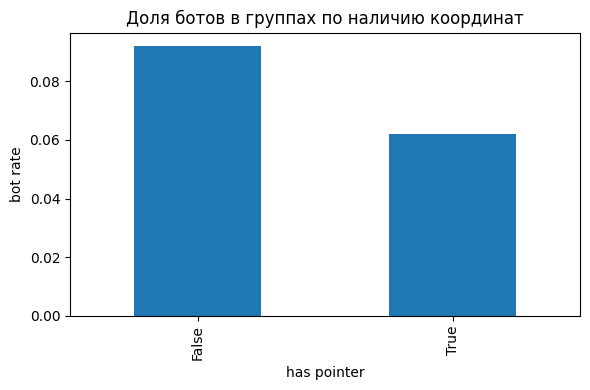

In [17]:
# ============================================================
# Диагностика групп по наличию координат указателя
# ============================================================

pointer_table = pd.crosstab(
    pd.Series(np.where(HAS_POINTER_TRAIN, 'Есть координаты', 'Нет координат'), name='Группа'),
    pd.Series(y, name='target'),
    margins=True
)
display(pointer_table)

pointer_rates = (
    pd.DataFrame({'has_pointer': HAS_POINTER_TRAIN, 'target': y})
    .groupby('has_pointer')
    .agg(n=('target', 'size'), bot_rate=('target', 'mean'))
)
display(pointer_rates.round(4))

pointer_rates['bot_rate'].plot(kind='bar', figsize=(6, 4))
plt.title('Доля ботов в группах по наличию координат')
plt.xlabel('has pointer')
plt.ylabel('bot rate')
plt.tight_layout()
plt.show()

## 10. Интерпретация признаков

CatBoost позволяет получить ориентировочную важность признаков. Это не причинная интерпретация, но полезный диагностический инструмент: он показывает, какие группы признаков чаще всего использовались деревьями.

Для иллюстрации обучим одну глобальную модель на всём train с `random_seed=42` и посмотрим топ признаков.

,feature,importance
132,v3_pointer_x_std,7.980387
26,delta_le_60s_ratio,4.610570
67,mean_item_repeats,3.713610
134,v3_pointer_x_range,3.532913
25,delta_le_30s_ratio,2.720354
68,category_entropy,2.232982
53,cookie_age_hours,2.168604
65,events_per_session,2.037523
130,v3_contact_ratio,2.032311
100,v3_dt_gt_5min_ratio,2.025747


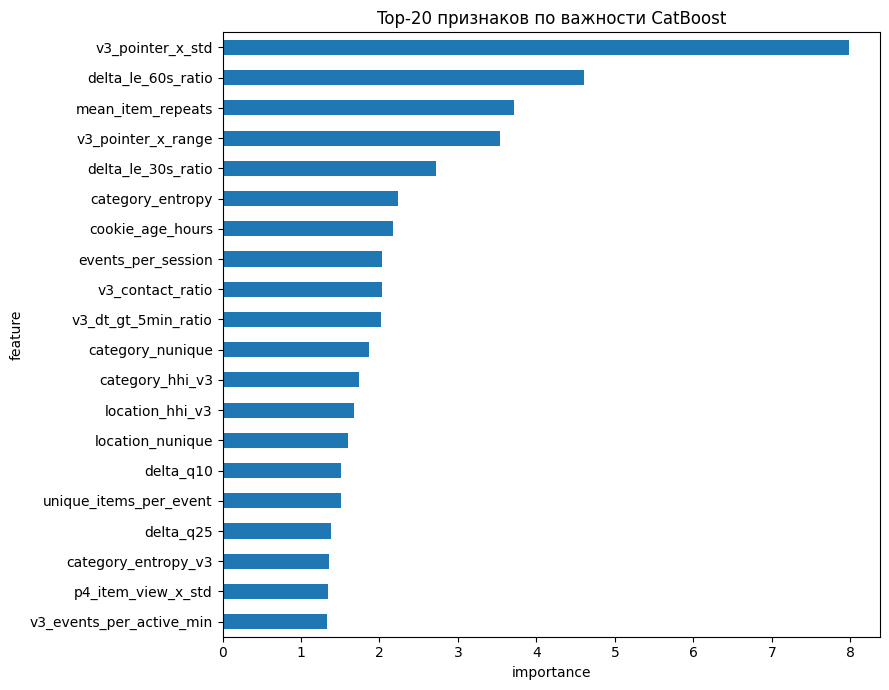

In [18]:
# ============================================================
# Важность признаков одной глобальной модели
# ============================================================

importance_model = new_model(42)
importance_model.fit(X_train[FEATURES], y)

importance_df = pd.DataFrame({
    'feature': FEATURES,
    'importance': importance_model.feature_importances_
}).sort_values('importance', ascending=False)

display(importance_df.head(25))

importance_df.head(20).sort_values('importance').plot(
    x='feature', y='importance', kind='barh', figsize=(9, 7), legend=False
)
plt.title('Top-20 признаков по важности CatBoost')
plt.xlabel('importance')
plt.tight_layout()
plt.show()

## 11. Проверенные, но не включённые идеи

В ходе исследования были рассмотрены дополнительные гипотезы. Не все из них вошли в итоговую модель.

### События `captcha_shown`

В полном журнале событий есть события показа капчи, и они сильно связаны с целевой переменной. Однако независимая проверка показала, что для обучающих cookie все такие события происходят **после окончания индивидуального окна наблюдения**. В test таких событий для test-cookie нет.

Поэтому события капчи не используются в признаках: это была бы информация из будущего относительно момента предсказания.

### Жизненный цикл объявления

Также проверялись признаки времени между первым просмотром объявления и последующими контактными действиями, а также длительность взаимодействия с конкретным `item_id`. Эти признаки дали локальные улучшения на отдельных периодах, но не обеспечили устойчивого прироста на хронологической валидации, поэтому в финальную конфигурацию не вошли.

In [19]:
# ============================================================
# Аудит captcha_shown относительно окон наблюдения
# ============================================================

captcha_events = events.loc[events.event_name.eq('captcha_shown'), ['cookie_id', 'event_ts']].copy()
print('Всего captcha_shown в полном events:', len(captcha_events))
print('Captcha внутри train-окон:', int(ev_train.event_name.eq('captcha_shown').sum()))
print('Captcha внутри test-окон:', int(ev_test.event_name.eq('captcha_shown').sum()))

joined = captcha_events.merge(
    train[['cookie_id', 'window_start_ts', 'window_end_ts', 'target']],
    on='cookie_id', how='inner', validate='many_to_one'
)
if len(joined) > 0:
    joined['position'] = np.select(
        [joined.event_ts.lt(joined.window_start_ts),
         joined.event_ts.ge(joined.window_end_ts)],
        ['before_window', 'after_window'],
        default='inside_window'
    )
    display(joined['position'].value_counts().to_frame('count'))
    cookie_with_future_captcha = set(joined.cookie_id)
    audit = train[['cookie_id', 'target']].copy()
    audit['has_future_captcha'] = audit.cookie_id.isin(cookie_with_future_captcha)
    display(pd.crosstab(audit.has_future_captcha, audit.target, margins=True))

Всего captcha_shown в полном events: 7928
Captcha внутри train-окон: 0
Captcha внутри test-окон: 0


,count
position,
after_window,7928


target,0,1,All
has_future_captcha,,,
False,10061,458,10519
True,131,441,572
All,10192,899,11091


## 12. Технические проверки воспроизводимости

Этот раздел вынесен ближе к концу, потому что он нужен не для выбора модели, а для контроля корректности решения.

Проверяется один важный технический момент: некоторые события имеют одинаковую временную отметку. В таких случаях исходные данные не позволяют строго восстановить порядок действий. Поэтому часть признаков переходов между событиями может зависеть от порядка строк в предоставленном файле.

Мы явно диагностируем такие признаки и оставляем это как ограничение решения. В финальной конфигурации используется исходный порядок предоставленного журнала, и ноутбук детерминированно воспроизводит результаты валидации.

In [22]:
# Диагностика может занимать несколько минут; она не изменяет обучающие таблицы.
shuffled_train = ev_train.sample(frac=1, random_state=42).reset_index(drop=True)
X_shuffled = build_feature_matrix(shuffled_train, train)
difference = ~np.isclose(X_train[FEATURES].to_numpy(dtype=float),
                         X_shuffled[FEATURES].to_numpy(dtype=float),
                         rtol=1e-10, atol=1e-10, equal_nan=True)
affected = [(col, int(difference[:, i].sum())) for i, col in enumerate(FEATURES) if difference[:, i].any()]
if affected:
    print('Признаки, чувствительные к порядку строк (название, число cookie):')
    display(pd.DataFrame(affected, columns=['Признак', 'Количество cookie']).sort_values('Количество cookie', ascending=False))
    print('Изменения не исправлялись автоматически во избежание незаметной смены обученной конфигурации.')
else:
    print('Признаки устойчивы к перемешиванию строк событий.')

Признаки, чувствительные к порядку строк (название, число cookie):


,Признак,Количество cookie
0,transition__search_results_view__item_view,108
1,transition__search_results_view__item_view_ratio,108
2,transition__item_view__photo_swipe,57
3,transition__item_view__photo_swipe_ratio,57
8,transition__item_view__favorite_add,31
9,transition__item_view__favorite_add_ratio,31
5,transition__item_view__seller_page_view_ratio,22
4,transition__item_view__seller_page_view,22
7,transition__item_view__contact_phone_show_ratio,18
6,transition__item_view__contact_phone_show,18


Изменения не исправлялись автоматически во избежание незаметной смены обученной конфигурации.


## 13. Соответствие требованиям проверки решения

В финальном решении явно учтены критерии, по которым оценивается работа:

- **Качество классификации.** Модель оптимизируется и сравнивается по официальной метрике `Precision@Recall≥0.70`.
- **Валидация.** Используется хронологическая схема: обучение всегда выполняется на более ранних датах, валидация — на более поздних.
- **Временные окна.** Все признаки строятся только по событиям внутри индивидуального окна наблюдения каждого cookie.
- **Пропуски и дубликаты.** Полные дубликаты событий учитываются диагностически и исключаются из поведенческих блоков, пропуски обрабатываются единообразно.
- **Категориальные данные.** Категории, локации, типы событий, платформы и поисковые запросы преобразуются в агрегированные числовые характеристики.
- **Feature engineering.** Признаки построены по истории событий и сгруппированы по поведенческим гипотезам.
- **Baseline.** Добавлено сравнение с простым baseline из двух признаков.
- **Воспроизводимость.** Зафиксированы `random_state`, список seed, версии библиотек и полный путь генерации `submission.csv`.
- **Ограничения.** Отдельно описаны события `captcha_shown`, чувствительность части последовательностных признаков к одинаковым timestamp и неоднородность координат указателя.

## 14. Обучение финальной модели и формирование submission

После выбора архитектуры модель обучается на всей обучающей выборке. Создаются два файла:

- `submission_hybrid.csv` — основной вариант, соответствующий выбранной гибридной архитектуре;
- `submission_global.csv` — контрольный вариант только с общей моделью.

Оба файла сохраняются в директорию `/content/submission_artifacts`.

In [23]:
full_mask = np.ones(len(train), dtype=bool)
final_scores = ensemble_predict(full_mask, X_test, HAS_POINTER_TEST)
OUTPUT_DIR = ROOT / 'submission_artifacts'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

hybrid_submission = pd.DataFrame({'cookie_id': test.cookie_id, 'score': final_scores['hybrid']})
global_submission = pd.DataFrame({'cookie_id': test.cookie_id, 'score': final_scores['global']})
for name, frame in [('submission_hybrid.csv', hybrid_submission), ('submission_global.csv', global_submission)]:
    assert frame.cookie_id.equals(test.cookie_id)
    assert np.isfinite(frame.score.to_numpy(dtype=float)).all()
    assert frame.score.between(0, 1).all()
    assert len(frame) == len(test)
    frame.to_csv(OUTPUT_DIR / name, index=False)
    print(name, '| строк:', len(frame), '| диапазон:', frame.score.min(), frame.score.max())

(OUTPUT_DIR / 'requirements.txt').write_text(
    f'numpy=={np.__version__}\npandas=={pd.__version__}\nscikit-learn=={sklearn.__version__}\ncatboost=={catboost.__version__}\n',
    encoding='utf-8'
)
(OUTPUT_DIR / 'python_version.txt').write_text(sys.version + '\n', encoding='utf-8')
print('Выходная директория:', OUTPUT_DIR)

submission_hybrid.csv | строк: 4909 | диапазон: 0.0005539011149255974 0.9988199346127319
submission_global.csv | строк: 4909 | диапазон: 0.00038555079775968846 0.9986343193532984
Выходная директория: /content/submission_artifacts


In [24]:
# ============================================================
# Финальная проверка формата submission
# ============================================================

for filename in ['submission_hybrid.csv', 'submission_global.csv']:
    path = OUTPUT_DIR / filename
    submission = pd.read_csv(path)
    assert list(submission.columns) == ['cookie_id', 'score']
    assert len(submission) == len(test)
    assert submission.cookie_id.equals(test.cookie_id.reset_index(drop=True))
    assert submission.cookie_id.is_unique
    assert submission.score.notna().all()
    assert np.isfinite(submission.score.to_numpy(dtype=float)).all()
    assert submission.score.between(0, 1).all()
    print(
        filename,
        '| OK | строк:', len(submission),
        '| min:', submission.score.min(),
        '| max:', submission.score.max()
    )

submission_hybrid.csv | OK | строк: 4909 | min: 0.0005539011149255 | max: 0.998819934612732
submission_global.csv | OK | строк: 4909 | min: 0.0003855507977596 | max: 0.9986343193532984


## 15. Итоговые выводы

В решении построен воспроизводимый пайплайн обнаружения автоматизированной активности по событиям внутри суточного окна наблюдения.

Ключевые элементы решения:

1. Строгая временная фильтрация событий по индивидуальному окну каждого cookie.
2. Набор поведенческих признаков, описывающих активность, временную динамику, поисковое поведение и координаты указателя.
3. Хронологическая валидация, соответствующая расположению test после train.
4. Гибридный ансамбль CatBoost, объединяющий общую модель и специализированные модели по наличию координат.
5. Финальный submission формируется детерминированно при фиксированных seed.

Основное ограничение решения — часть признаков переходов между типами действий чувствительна к порядку событий с одинаковыми timestamp. Это ограничение явно диагностируется и описывается в ноутбуке.

Основной файл для отправки: `submission_hybrid.csv`.